# Observed vs. true fluorescence lifetime in homoFRET exhibiting systems

In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

Assumes an infinitesimally short laser pulse that assures only one fluorophore to be excited per pulse. Another pulse
starts only if all fluorophores are in their ground state.
This simulation is suited to demonstrate observed fluorescence lifetimes of homo-FRET experiments.
This simulation is NOT suited to demonstrate effects of energy transfers that are not homo-FRET, since they cannot
occur. Note: the observed fluorescence lifetime of systems without homo-FRET should equal the true fluorescence
lifetime.

TCSPC experiment uses a pulsed laser - different transition matrix depending on point in time. Doesn't work because of a few things, e.g., drawn times larger than next pulse have to be discarded, leading to false statistics

In [2]:
def modify_transition_matrix(transition_set):
    """
    Modifies the transition matrix in a way that prevents multiple fluorophores to be 
    in a different photophysical state than the ground state simultaneously. This is 
    achieved by setting all excitation rates that do not effect an all ground state 
    fluorophore configuration to zero.
    """
    df = transition_set.combined_state_transitions_df
    excitations = df[df['abbreviation'] == 'EXC']
    indices_to_modify = excitations.index.values[transition_set.fluorophore_system.count:]
    transition_rate_matrix = transition_set.transition_matrix * np.expand_dims(transition_set.row_sums, axis=1)
    transition_rate_matrix[:, indices_to_modify] = 0
    modified_row_sums = transition_rate_matrix.sum(axis=1)
    modified_transition_matrix = np.divide(transition_rate_matrix, np.expand_dims(modified_row_sums, axis=1),
                                            out=np.zeros_like(transition_rate_matrix), where=modified_row_sums != 0)
    return modified_transition_matrix, modified_row_sums

def run(transition_set, modified_transition_matrix, modified_row_sums, size, seed):
    start_at = tuple(np.zeros(shape=transition_set.fluorophore_system.count, dtype=int))
    df = transition_set.combined_state_transitions_df
    start_index = df[df['final_state'] == start_at].index[0]
    time_series, transition_series = si.direct_method_steps(transition_matrix=modified_transition_matrix,
                                                            row_sums=modified_row_sums,
                                                            start_index=start_index, size=size, seed=seed)
    return time_series, transition_series

def get_observed_lifetimes(transition_series, time_series, transition_set):
    """
    Get times between photon-driven excitation and fluorescent emission not considering whether the emission comes
    from the originally excited fluorophore.
    """
    df = transition_set.combined_state_transitions_df
    excitation_values = df[df['abbreviation'] == 'EXC'].index.values
    fluorescence_values = df[df['abbreviation'] == 'FLU'].index.values
    excitation_indices = np.in1d(transition_series, excitation_values).nonzero()[0]
    emission_indices = np.in1d(transition_series, fluorescence_values).nonzero()[0]
    excitation_times = time_series[excitation_indices + 1]
    emission_times = time_series[emission_indices + 1]
    pre_emission_times = time_series[emission_indices]
    true_fluorescence_lifetime = np.mean(emission_times - pre_emission_times)
    corresponding_excitation_time_indices = np.searchsorted(excitation_times, emission_times, side='right') - 1
    corresponding_excitation_times = excitation_times[corresponding_excitation_time_indices]

    observed_lifetimes = emission_times - corresponding_excitation_times

    return true_fluorescence_lifetime, observed_lifetimes

def get_transition_probabilities(transition_df, fluorophore_system):
    """
    Gets the probabilities of homoFRET and fluorescent deexcitation and the fluorescence lifetime.
    Note: the values returned reflect a setup where only one fluorophore is excited at a time. This means that if a
    fluorophore is in S1, all other fluorophores are, at all times, in S0. Hence, if the rate of homoFRET is non-zero,
    it has to be considered constantly and alters the fluorescence lifetime and probability of fluorescence.
    Additionally, if more than 2 fluorophores are present, a total FRET rate is calculated depending on the distances.

    Parameters
    ----------
    transition_df : pd.DataFrame
        Dataframe of transitions containing their id as index and their other attributes as columns
        (see src.transitions.Transition).
    fluorophore_system : src.fluolrophores.FluorophoreSystem
        Container for attributes of multiple, interrelated fluorophores.

    Returns
    -------
    fluorescence_lifetime : float
        The fluorescence lifetime (may differ from the observed lifetime, see note above).
    hfret_probability : float
        The probability of homoFRET (see note above).
    fluorescence_probability : float
        The probability of fluorescent deexcitation (see note above).
    """
    distances, occurrences = np.unique(list(fluorophore_system.distances.values()), return_counts=True)
    occurrences = occurrences / fluorophore_system.count

    df = transition_df
    fluorescence_rate = df[df['abbreviation'] == 'FLU']['rate'].values[0]
    non_et_s1_rates = df[df['initial_state'] == tr.SingleState.S1]['rate']
    et_s1_s0_transitions = df[df['initial_state'] == tr.PairedState.S1_S0]
    indices = np.where(et_s1_s0_transitions['distance'].values == distances)[0]
    et_s1_s0_rate_sum = (et_s1_s0_transitions['rate'] * occurrences[indices]).sum()
    fluorescence_lifetime = 1 / (non_et_s1_rates.sum() + et_s1_s0_rate_sum)
    hfret_probability = et_s1_s0_rate_sum * fluorescence_lifetime
    fluorescence_probability = fluorescence_rate * fluorescence_lifetime

    return fluorescence_lifetime, hfret_probability, fluorescence_probability

# def predict(self, accuracy=10, size=10, seed=None):
#     """
#     Compute times between photon-driven excitation and fluorescent emission not considering whether the emission
#     comes from the originally excited fluorophore.

#     Parameters
#     ----------
#     accuracy : int
#         The accuracy of the prediction. Higher energy transfer rates need higher accuracy to accomplish the same
#         quality of prediction.
#     size : int
#         The number of random variates generated.
#     seed : None, int, BitGenerator, Generator
#         A seed to initialize the BitGenerator.

#     Returns
#     -------
#     None
#     """
#     from scipy.stats import erlang
#     self.predicted_true_fluorescence_lifetime, hfret_probability, fluorescence_probability = \
#         get_transition_probabilities(self.transition_set.transition_df, self.transition_set.fluorophore_system)
#     rng = np.random.default_rng(seed)
#     probabilities = []
#     distributions = []
#     for i in range(accuracy):
#         probability = fluorescence_probability * hfret_probability**i  # x**0 = 1
#         probabilities.append(probability)
#         distribution = erlang(a=i+1, scale=self.predicted_true_fluorescence_lifetime)
#         distributions.append(distribution)
#     weights = probabilities / np.sum(probabilities)  # otherwise, probabilites do not add up to 1
#     random_numbers = np.random.uniform(0, 1, size)
#     cumulative_probabilities = np.cumsum(weights)
#     self.predicted_obs_lifetimes = np.ones(size)
#     for i in range(size):
#         index = np.searchsorted(cumulative_probabilities, random_numbers[i])
#         self.predicted_obs_lifetimes[i] = distributions[index].rvs(size=1, random_state=rng)


In [3]:
fluorophores = fl.construct_fluorophores(name='cy5', distance=10, count=4)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(transition_type=tr.TransitionType.EXCITATION, rate=1e9,
                           fluorophore_ids=[0, 1, 2, 3])
fluorescence = tr.Transition(transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
                             rate=1e9, fluorophore_ids=[0, 1, 2, 3])
hfret = tr.Transition(transition_type=tr.TransitionType.FRET,
                      rate=1e10,
                      fluorophore_ids=[(0, 1), (0, 2), (1, 0), (1, 3),
                                       (2, 0), (2, 3), (3, 1), (3, 2)])
hfret_2 = tr.Transition(transition_type=tr.TransitionType.FRET,
                      rate=0.5e10,
                      fluorophore_ids=[(0, 3), (1, 2), (2, 1), (3, 0)])
transitions = {'cy5': [excitation, fluorescence],
               'D: cy5, A: cy5, dist: 10.0': [hfret],
               'D: cy5, A: cy5, dist: 14.142': [hfret_2]}

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

mod_transition_matrix, mod_row_sums = modify_transition_matrix(transition_set)
time_series, transition_series = run(transition_set, mod_transition_matrix, mod_row_sums,
                                     size=1000, seed=3)
true_tau, obs_tau = get_observed_lifetimes(transition_series, time_series, transition_set)

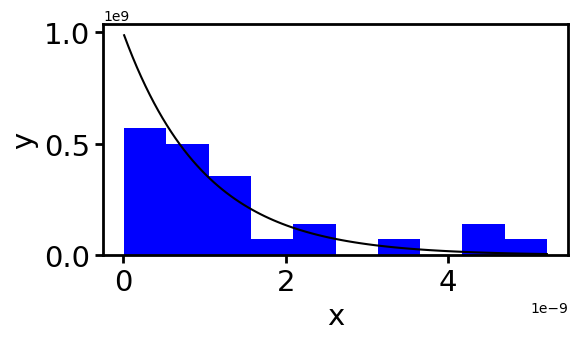

In [4]:
from scipy.stats import expon
distr = expon(scale=1e-9)
ax = fi.universal_figure(type_='hist', data=obs_tau, density=True,
                         plot_distribution=distr)

In [ ]:
"""    observed_lifetimes : 1-D array_like
        Simulated times between photon-driven excitation and fluorescent emission not considering whether the emission
        comes from the originally excited fluorophore.
    predicted_obs_lifetimes : 1-D array_like
        Computed times between photon-driven excitation and fluorescent emission not considering whether the emission
        comes from the originally excited fluorophore.
    true_fluorescence_lifetime : float
        The true (not observed) fluorescence lifetime extracted from simulated data.
    predicted_true_fluorescence_lifetime : float
        The computed true (not observed) fluorescence lifetime. """

array([[<Axes: title={'center': 'simulation'}, xlabel='observed lifetime [s]', ylabel='PD'>]],
      dtype=object)

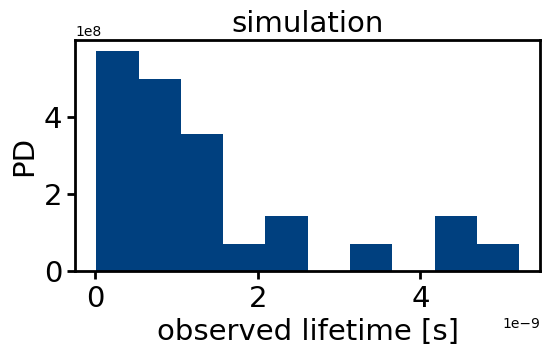

In [6]:

def plot(mode='simulation', **kwargs):
    """
    Plot histogram of simulated or predicted observed lifetimes.

    Parameters
    ----------
    mode : str
        One of 'simulation', 'prediction'.
    kwargs : src.figure.universal_figure arguments

    Returns
    -------
    axes : np.ndarray
        Contains matplotlib.axes._subplots.AxesSubplots.
    """
    kwargs.setdefault('type_', 'hist')
    kwargs.setdefault('ylabel', 'PD')
    kwargs.setdefault('density', True)
    kwargs.setdefault('xlabel', 'observed lifetime [s]')
    if mode == 'simulation':
        data = obs_tau
        kwargs.setdefault('title', 'simulation')
    elif mode == 'prediction':
        #data = self.predicted_obs_lifetimes
        kwargs.setdefault('title', 'prediction')
    else:
        raise ValueError('mode has to be one of "simulation" or "prediction"')
    axes = fi.universal_figure(data=data, **kwargs)

    return axes

axes = plot()
plot('simulation', axes=axes, color='g', alpha=0.5)

In [8]:
energy_transfer_rates = np.logspace(4, 12, num=9)
fluorophores = fl.construct_fluorophores('cy5', 10, 2)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
excitation = tr.Transition(transition_type=tr.TransitionType.EXCITATION,
                           rate=1e9, fluorophore_ids=[0, 1])
fluorescence = tr.Transition(transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
                             rate=3e8, fluorophore_ids=[0, 1])
ic = tr.Transition(transition_type=tr.TransitionType.INTERNAL_CONVERSION_S,
                  rate=7e8, fluorophore_ids=[0, 1])

In [12]:
calculated_true_lifetimes = []
calculated_obs_lifetimes = []
unchanged_lifetimes = []
simulated_obs_lifetimes = []
simulated_true_lifetimes = []
for energy_transfer_rate in energy_transfer_rates:
    hfret = tr.Transition(transition_type=tr.TransitionType.FRET,
                          rate=energy_transfer_rate, fluorophore_ids=[(0, 1), (1, 0)])
    transitions = {'cy5': [excitation, fluorescence, ic], 'D: cy5, A: cy5, dist: 10.0': [hfret]}
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    mod_transition_matrix, mod_row_sums = modify_transition_matrix(transition_set)
    time_series, transition_series = run(size=100000, seed=100, transition_set=transition_set, modified_transition_matrix=mod_transition_matrix, modified_row_sums=mod_row_sums)
    true_tau, obs_tau = get_observed_lifetimes(transition_series=transition_series, time_series=time_series, transition_set=transition_set)
    #predict(accuracy=100000)
    
    # calculated_obs_lifetimes.append(np.mean(tcspc.predicted_obs_lifetimes))
    # calculated_true_lifetimes.append(tcspc.predicted_true_fluorescence_lifetime)
    # simulated_obs_lifetimes.append(np.mean(tcspc.observed_lifetimes))
    # simulated_true_lifetimes.append(tcspc.true_fluorescence_lifetime)
    # unchanged_lifetimes.append(1e-9)

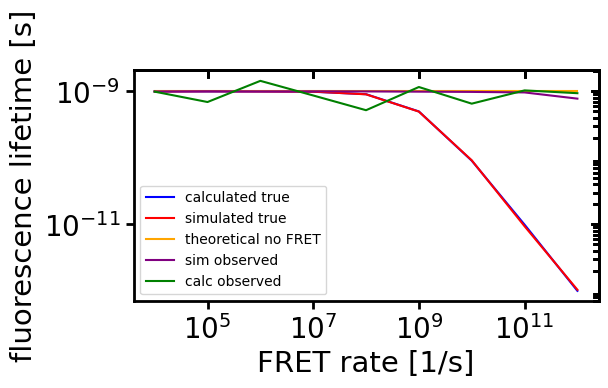

In [19]:
axes = fi.universal_figure(type_='line', data=[energy_transfer_rates, calculated_true_lifetimes], yscale='log', xscale='log', label='calculated true')
axes = fi.universal_figure(type_='line', data=[energy_transfer_rates, simulated_true_lifetimes], axes=axes, color='red', label='simulated true')
axes = fi.universal_figure(type_='line', data=[energy_transfer_rates, unchanged_lifetimes], axes=axes, color='orange', label='theoretical no FRET')
axes = fi.universal_figure(type_='line', data=[energy_transfer_rates, simulated_obs_lifetimes], axes=axes, color='purple', label='sim observed')
axes = fi.universal_figure(type_='line', data=[energy_transfer_rates, calculated_obs_lifetimes], axes=axes, color='green', label='calc observed', legend=True,
                           xlabel='FRET rate [1/s]', ylabel='fluorescence lifetime [s]')